 ## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import joblib
import json

## Load Dataset

In [2]:
df = pd.read_csv(
    "../../data/processed/feature_engineered_unscaled.csv",
    parse_dates=[0],
    index_col=0
)

df = df.sort_index()
df.head()

,demand,demand_diff,lag_1,lag_48,rolling_mean_48,hour,day_of_week,month
timestamp,,,,,,,,
2009-01-02 00:00:00,30659.0,732.0,29927.0,33939.0,33459.395833,0,4,1
2009-01-02 00:30:00,30506.0,-153.0,30659.0,34072.0,33385.104167,0,4,1
2009-01-02 01:00:00,30171.0,-335.0,30506.0,33615.0,33313.354167,1,4,1
2009-01-02 01:30:00,29443.0,-728.0,30171.0,32526.0,33249.125000,1,4,1
2009-01-02 02:00:00,29273.0,-170.0,29443.0,31877.0,33194.875000,2,4,1


## Select Target Variable

In [3]:
target = "demand"

series = df[[target]].dropna()
series.head()

,demand
timestamp,
2009-01-02 00:00:00,30659.0
2009-01-02 00:30:00,30506.0
2009-01-02 01:00:00,30171.0
2009-01-02 01:30:00,29443.0
2009-01-02 02:00:00,29273.0


## Train-Test Split

In [4]:
SPLIT_RATIO = 0.8
split_idx = int(len(series) * SPLIT_RATIO)
SPLIT_TIMESTAMP = series.index[split_idx]
print("split:", SPLIT_TIMESTAMP)

split: 2021-11-16 14:00:00


## Apply the Split

In [5]:
train_series = series.loc[:SPLIT_TIMESTAMP]
test_series = series.loc[SPLIT_TIMESTAMP:].iloc[1:]

print("Train samples:", len(train_series))
print("Test samples:", len(test_series))

Train samples: 225677
Test samples: 56419


## Scale Time-Series Data

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
test_scaled = scaler.transform(test_series.values.reshape(-1, 1))
print(train_scaled.shape)
print(test_scaled.shape)

(225677, 1)
(56419, 1)


## Create Sequences for LSTM

In [7]:
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 48  # one day of half-hourly data

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)

## Verify LSTM Input Shape

In [8]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (225629, 48, 1)
y_train shape: (225629,)


## Design LSTM Model Architecture

In [9]:
model = Sequential([
    LSTM(
        units=50,
        activation="tanh",
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(1)
])

model.summary()


c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Deep Learning Model

In [10]:
model.compile(
    optimizer="adam",
    loss="mse"
)

## Callbacks


In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Train the LSTM Model

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 122s 21ms/step - loss: 0.0022 - val_loss: 1.3648e-04
Epoch 2/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 115s 20ms/step - loss: 3.1889e-04 - val_loss: 1.1132e-04
Epoch 3/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 132s 23ms/step - loss: 2.9349e-04 - val_loss: 8.4089e-05
Epoch 4/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 125s 22ms/step - loss: 2.7752e-04 - val_loss: 6.5029e-05
Epoch 5/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 118s 21ms/step - loss: 2.7141e-04 - val_loss: 8.6714e-05
Epoch 6/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 112s 20ms/step - loss: 2.6490e-04 - val_loss: 6.4717e-05
Epoch 7/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 114s 20ms/step - loss: 2.6139e-04 - val_loss: 7.4631e-05
Epoch 8/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 119s 21ms/step - loss: 2.5449e-04 - val_loss: 8.0917e-05
Epoch 9/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 118s 21ms/step - loss: 2.4613e-04 - val_loss: 6.2975e-05
Epoch 10/50
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 119s 21ms/step - loss: 2.4351e-04 - val_loss: 9.3345e-05
Epoch 11/50
5

## Plot Learning Curves


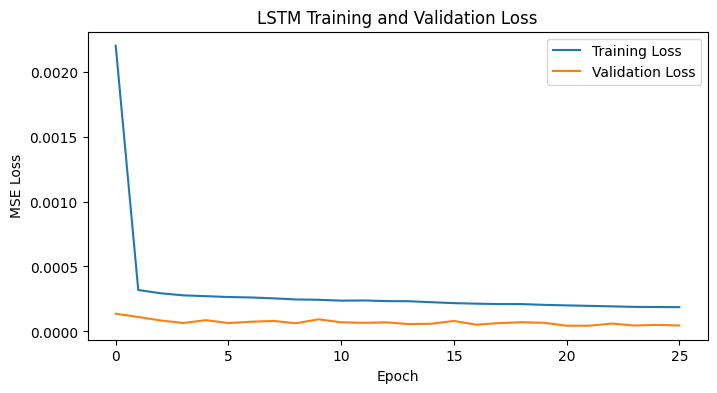

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

## Evaluate on Test Set

In [14]:
lstm_preds_scaled = model.predict(X_test)

# Inverse scaling
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
mae = mean_absolute_error(y_test_actual, lstm_preds)
mape = mean_absolute_percentage_error(y_test_actual, lstm_preds)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2%}")

1762/1762 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step
RMSE: 351.74, MAE: 272.66, MAPE: 1.15%


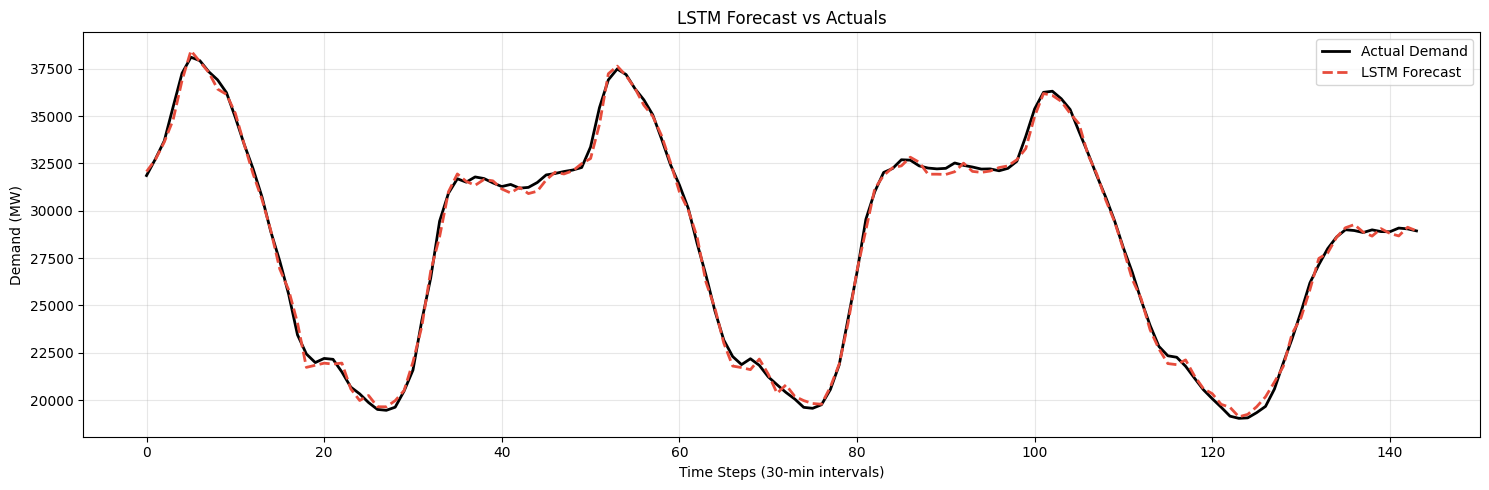

In [15]:
# Micro-Level Plot 
window = 144 

plt.figure(figsize=(15, 5))
plt.plot(y_test_actual[:window], label="Actual Demand", color='black', linewidth=2)
plt.plot(lstm_preds[:window], label="LSTM Forecast", color='#e74c3c', linestyle="--", linewidth=2)
plt.title("LSTM Forecast vs Actuals")
plt.ylabel("Demand (MW)")
plt.xlabel("Time Steps (30-min intervals)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Save metrics
lstm_results = {
    'model_name': 'LSTM',
    'rmse': float(rmse),
    'mae': float(mae),
    'mape': float(mape)
}

with open('../../results/lstm_metrics.json', 'w') as f:
    json.dump(lstm_results, f)

# Save predictions and actual values
np.save('../../results/lstm_preds.npy', lstm_preds[:100])
np.save('../../results/actual_values.npy', y_test_actual[:100])

## Save the Model

In [17]:
model.save("lstm_model.keras")

joblib.dump(scaler, 'scaler.pkl') 

print("Model and Scaler saved")

Model and Scaler saved
